## Genomics

Leukemia is a cancer of blood-generating tissues. Over 475,000 Americans have Leukemia or are in remission from it. It accounts for 3.3% of all new cancer cases and 3.8% of cancer deaths, with an estimated 66,890 new cases and 23,540 deaths in the U.S. in 2025.

There are two major leukemia families: Acute Lymphoblastic Leukemia (ALLB and ALLT, or ALL), which is cancer of immature lymphoid cells, and Acute Myeloid Leukemia (AML), which is cancer of cancer of immature myeloid cells.

Golub et al. (*Science*, 1999) popularized a dataset including about 7000 genes from 72 patients. The goal is to use genomics data to predict which patients are at risk of ALL versus AML, because the distinction is critical for timely and effective treatment.

1. Load the `golub.csv` dataset. Relabel all instances of ALLB and ALLT as 0, and all instances of ALL as 1. This is the target variable.

2. Use Linear Regression of the target variable on all of the genes provided. What is your mean squared error? Make a kernel density plot of your residuals, and a scatter plot comparing predicted and actual outcomes.

My mean squared error came out to `1.25*10^-30`, meaning there was essentially no error. This is supported by my plot, which shows two distinct points of `(0,0)` and `(1,1)`, showing that the predictions were always correct.

3. Use cross validation to compute the mean squared error of the linear model. Discuss your results from the perspective of the bias variance trade-off.

The cross validation mean squared error returned an average MSE of `0.0601`, which is a drastic difference than the previous value obtained. This indicates that the model does not do well with unseen data, and is potentially overfitting to the gievn data. This may also be due to the sheer number of features in comparison to the number of observations. In terms of the bias-variance tradeoff, our model can easily classify the target variable due to the large number of features, showing low bias. However, the model exhibits high variance and is not robust to unseen data, as seen with the fluctuation of the MSE after running cross validation.

4. Use the cross validated LASSO to select a set of highly predictive genes. Which set of genes is selected? How many genes are discarded from the model? Make a scatterplot of your predictions versus the actual values.

The model discards 7095 genes, selecting the set of genes with the most predictive impact on the target variable.

5. Make a plot that shows the cross validated MSE as $alpha$ varies. For what values of $\alpha$ is the LASSO underfitting? Overfitting? What is the optimal penality hyperparameter that minimizes expected MSE?

The optimal alpha value is found to be `105.24`. The graph is overfitting for very small alpha values, like those less than `10`. The graph is underfitting for alpha values a bit greater than `10^3`.

6. Explain why linear regression performs perfectly on the training set, but the LASSO provides better predictions overall.

The linear regression performed perfectly because of the over 7000 features in comparison to the 72 samples. This essentially led to memorization of the labels and very low MSE. On the other hand, LASSO assigns coefficients of `0` to certain features, thus discarding them from the model. This prevents overfitting and increases the model's predictive powers.

7. Why do regularization methods lend themselves to scenarios like precision health?

Regularization methods are invaluable for precision health analytics because of the large number of features in combination with little samples. Similar to how LASSO improved the predictive power of the model, other regularization methods reduce overfitting and performs feature selection to keep only the essential features in prediction.

8. What are the risks of applying methods like the Lasso to precision health questions, where interventions will then be taken to optimize patient health?

Using LASSO to determine the actual correlated features may lead to false emphasis on those features. Additionally, no prediction model will ever be able to perfectly predict a patient's outcome, especially if there are few samples. Any discrepancies in prediction leads to ethical considerations.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import statsmodels.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import LassoCV

MSE: 1.2522824482837894e-30


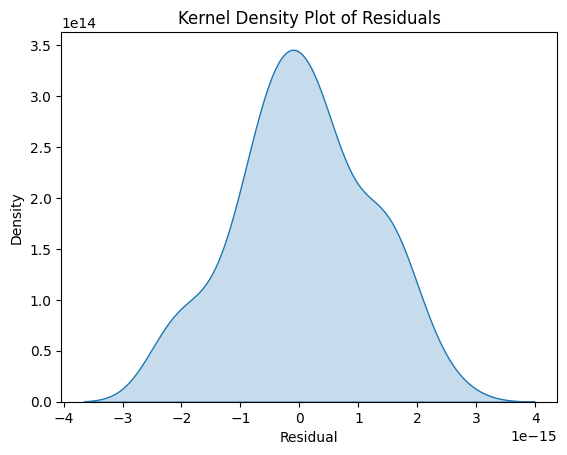

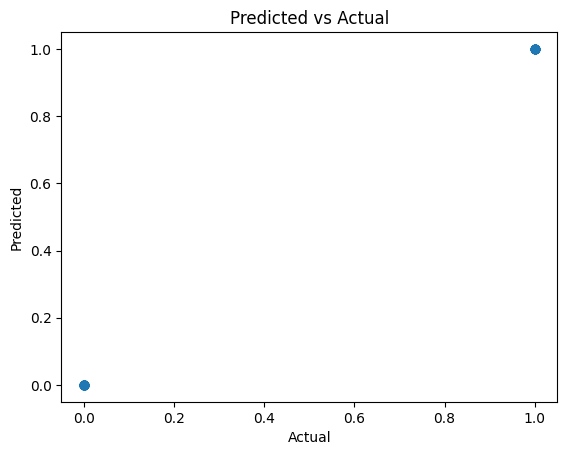

Fold MSEs: [0.04872133 0.07295289 0.04721866 0.04686773 0.08485489]
Mean CV MSE: 0.06012309872062149
Optimal alpha: 105.24436668425457
Selected genes: ['HG3549-HT3751_at', 'J04164_at', 'L38941_at', 'M11147_at', 'M11722_at', 'M17733_at', 'M19507_at', 'M26602_at', 'M27891_at', 'M33680_at', 'M63138_at', 'M77232_rna1_at', 'M91036_rna1_at', 'M96326_rna1_at', 'U14968_at', 'X04500_at', 'X17042_at', 'X78992_at', 'Z70759_at', 'L06797_s_at', 'D49824_s_at', 'M25079_s_at', 'X57351_s_at', 'V00594_s_at', 'U05255_s_at', 'X03689_s_at', 'M14328_s_at', 'M14483_rna1_s_at', 'M26708_s_at', 'Y00787_s_at', 'Z19554_s_at', 'X56681_s_at', 'HG2887-HT3031_at', 'M33600_f_at']
Number of genes discarded: 7095
Lasso MSE: 0.00859303029698961


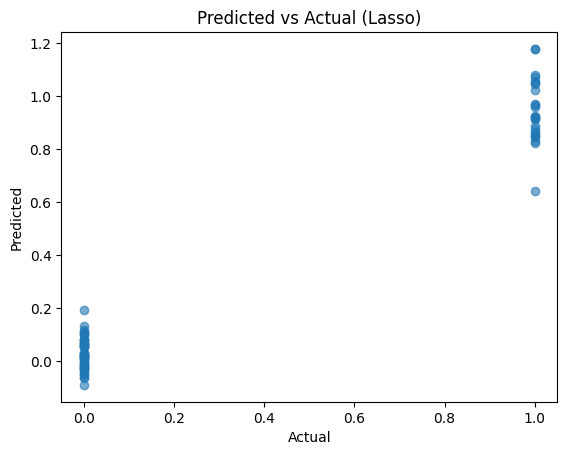

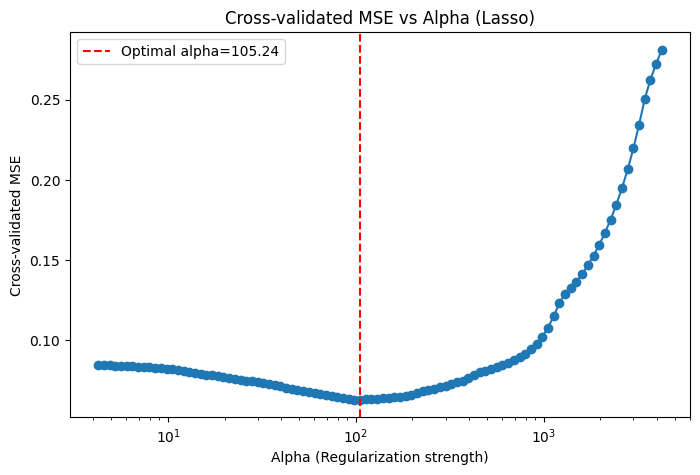

In [ ]:
# QUESTION 1
df = pd.read_csv('golub.csv')
df['cancer'] = df['cancer'].map({'allB': 0, 'allT': 0, 'aml': 1})

# QUESTION 2
y = df['cancer']

non_genes = ['Samples', 'BM.PB', 'Gender', 'Source', 'tissue.mf', 'cancer']
X = df.drop(columns=non_genes)

model = LinearRegression()
model.fit(X, y)

y_pred = model.predict(X)

mse = mean_squared_error(y, y_pred)
print("MSE:", mse)

residuals = y - y_pred

sns.kdeplot(residuals, fill=True)
plt.title("Kernel Density Plot of Residuals")
plt.xlabel("Residual")
plt.show()

plt.scatter(y, y_pred, alpha=0.5)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual")
plt.show()

# QUESTION 3
model = LinearRegression()

cv_mse = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')

print("Fold MSEs:", cv_mse)
print("Mean CV MSE:", np.mean(cv_mse))

# QUESTION 4
lasso = LassoCV(cv=5, random_state=42, max_iter=10000)
lasso.fit(X, y)
print("Optimal alpha:", lasso.alpha_)

selected_mask = lasso.coef_ != 0

selected_genes = X.columns[selected_mask]
print("Selected genes:", list(selected_genes))

num_discarded = np.sum(lasso.coef_ == 0)
print("Number of genes discarded:", num_discarded)

y_pred = lasso.predict(X)

mse = mean_squared_error(y, y_pred)
print("Lasso MSE:", mse)

plt.scatter(y, y_pred, alpha=0.6)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Predicted vs Actual (Lasso)")
plt.show()

# QUESTION 5

mean_mse_per_alpha = lasso.mse_path_.mean(axis=1)

# Alphas tested
alphas = lasso.alphas_

# Plot
plt.figure(figsize=(8,5))
plt.plot(alphas, mean_mse_per_alpha, marker='o')
plt.xscale('log')  # alpha is typically log-scaled
plt.xlabel("Alpha (Regularization strength)")
plt.ylabel("Cross-validated MSE")
plt.title("Cross-validated MSE vs Alpha (Lasso)")
plt.axvline(lasso.alpha_, color='red', linestyle='--', label=f'Optimal alpha={lasso.alpha_:.2f}')
plt.legend()
plt.show()